# MovieLens

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

c:\Users\rafae\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\rafae\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
movies  = pd.read_csv("movies.csv")   # movieId, title, genres
ratings = pd.read_csv("ratings.csv")  # userId, movieId, rating, timestamp
tags    = pd.read_csv("tags.csv")      # userId, movieId, tag, timestamp
links   = pd.read_csv("links.csv")     # movieId, imdbId, tmdbId

In [4]:
print("MOVIES")
display(movies.head())
print(movies.shape)
print()

print("LINKS")
display(links.head())
print(links.shape)

print("RATINGS")
display(ratings.head())
print(ratings.shape)
print()

print("TAGS")
display(tags.head())
print(tags.shape)
print()

MOVIES


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


(9742, 3)

LINKS


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


(9742, 3)
RATINGS


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


(100836, 4)

TAGS


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


(3683, 4)



Não precisámos de utilizar o dataset do links porque não vai ser necessário para caracterizar os dados, é apenas um identificador externo.

ver valores nulos

In [5]:
print("Null values in movies:")
print(movies.isnull().sum())
print()

print("Null values in ratings:")
print(ratings.isnull().sum())
print()

print("Null values in tags:")
print(tags.isnull().sum())
print()

Null values in movies:
movieId    0
title      0
genres     0
dtype: int64

Null values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Null values in tags:
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64



ver duplicados

In [6]:
print("Duplicated values in movies:")
print(movies.duplicated().sum())
print()

print("Duplicated values in ratings:")
print(ratings.duplicated().sum())
print()

print("Duplicated values in tags:")
print(tags.duplicated().sum())
print()

Duplicated values in movies:
0

Duplicated values in ratings:
0

Duplicated values in tags:
0



compreender cada um dos datasets

In [7]:
print("Estatistical values in movies:")
print(movies.describe())
print()

print("Estatistical values in ratings:")
print(ratings.describe())
print()

print("Estatistical values in tags:")
print(tags.describe())
print()

Estatistical values in movies:
             movieId
count    9742.000000
mean    42200.353623
std     52160.494854
min         1.000000
25%      3248.250000
50%      7300.000000
75%     76232.000000
max    193609.000000

Estatistical values in ratings:
              userId        movieId         rating     timestamp
count  100836.000000  100836.000000  100836.000000  1.008360e+05
mean      326.127564   19435.295718       3.501557  1.205946e+09
std       182.618491   35530.987199       1.042529  2.162610e+08
min         1.000000       1.000000       0.500000  8.281246e+08
25%       177.000000    1199.000000       3.000000  1.019124e+09
50%       325.000000    2991.000000       3.500000  1.186087e+09
75%       477.000000    8122.000000       4.000000  1.435994e+09
max       610.000000  193609.000000       5.000000  1.537799e+09

Estatistical values in tags:
            userId        movieId     timestamp
count  3683.000000    3683.000000  3.683000e+03
mean    431.149335   27252.013576  1

dataset tags

separar os tags individuais

In [8]:
tags['tag'] = tags['tag'].apply(
    lambda x: tuple(t.strip() for t in x.lower().split('/'))
    if isinstance(x, str) else tuple()
)

tags.head()

,userId,movieId,tag,timestamp
0,2,60756,"(funny,)",1445714994
1,2,60756,"(highly quotable,)",1445714996
2,2,60756,"(will ferrell,)",1445714992
3,2,89774,"(boxing story,)",1445715207
4,2,89774,"(mma,)",1445715200


dataset movies:

separar os genres com tupla

In [9]:
movies['genres'] = movies['genres'].apply(
    lambda x: tuple(t.strip() for t in x.lower().split('|')) 
    if isinstance(x, str) and x != "(no genres listed)" else tuple()
)

movies.head()


,movieId,title,genres
0,1,Toy Story (1995),"(adventure, animation, children, comedy, fantasy)"
1,2,Jumanji (1995),"(adventure, children, fantasy)"
2,3,Grumpier Old Men (1995),"(comedy, romance)"
3,4,Waiting to Exhale (1995),"(comedy, drama, romance)"
4,5,Father of the Bride Part II (1995),"(comedy,)"


Adicionar ranking médio a cada filme

In [10]:
movies['avg_rating'] = movies['movieId'].map(ratings.groupby('movieId')['rating'].mean())

movies.head()


,movieId,title,genres,avg_rating
0,1,Toy Story (1995),"(adventure, animation, children, comedy, fantasy)",3.920930
1,2,Jumanji (1995),"(adventure, children, fantasy)",3.431818
2,3,Grumpier Old Men (1995),"(comedy, romance)",3.259615
3,4,Waiting to Exhale (1995),"(comedy, drama, romance)",2.357143
4,5,Father of the Bride Part II (1995),"(comedy,)",3.071429


adicionar a coluna data

In [11]:
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype('Int64')

movies.head()

,movieId,title,genres,avg_rating,year
0,1,Toy Story (1995),"(adventure, animation, children, comedy, fantasy)",3.920930,1995
1,2,Jumanji (1995),"(adventure, children, fantasy)",3.431818,1995
2,3,Grumpier Old Men (1995),"(comedy, romance)",3.259615,1995
3,4,Waiting to Exhale (1995),"(comedy, drama, romance)",2.357143,1995
4,5,Father of the Bride Part II (1995),"(comedy,)",3.071429,1995


In [12]:
movies.describe()

,movieId,avg_rating,year
count,9742.000000,9724.000000,9729.0
mean,42200.353623,3.262448,1994.613629
std,52160.494854,0.869874,18.535219
min,1.000000,0.500000,1902.0
25%,3248.250000,2.800000,1988.0
50%,7300.000000,3.416667,1999.0
75%,76232.000000,3.911765,2008.0
max,193609.000000,5.000000,2018.0


In [13]:
print("Null values in movies:")
print(movies.isnull().sum())
print()

Null values in movies:
movieId        0
title          0
genres         0
avg_rating    18
year          13
dtype: int64



verificou-se os filmes sem ano.

In [14]:
# Filmes sem ano
movies[movies['year'].isna()]


,movieId,title,genres,avg_rating,year
6059,40697,Babylon 5,"(sci-fi,)",2.25,<NA>
9031,140956,Ready Player One,"(action, sci-fi, thriller)",3.50,<NA>
9091,143410,Hyena Road,(),2.00,<NA>
9138,147250,The Adventures of Sherlock Holmes and Doctor W...,(),5.00,<NA>
9179,149334,Nocturnal Animals,"(drama, thriller)",3.00,<NA>
9259,156605,Paterson,(),4.50,<NA>
9367,162414,Moonlight,"(drama,)",5.00,<NA>
9448,167570,The OA,(),4.00,<NA>
9514,171495,Cosmos,(),4.50,<NA>
9515,171631,Maria Bamford: Old Baby,(),1.00,<NA>


Notou-se que esses filmes geralmente não tinham data porque estava incompleta a sua descrição ou porque na verdade eram séries. Portanto adicionámos data que vimos manualmente aos que eram filmes completos e só faltava a data, Ready Player One, Nocturnal Animals, Moonlight, e os outros retirámos.

In [15]:
year_fixes = {
    'Ready Player One': 2018,
    'Nocturnal Animals': 2016,
    'Moonlight': 2016
}

for title, year in year_fixes.items():
    mask = movies['title'] == title
    movies.loc[mask, 'year'] = year
    movies.loc[mask, 'title'] = f"{title} ({year})"

movies[movies['title'].str.contains('Ready Player|Nocturnal|Moonlight')][['movieId', 'title', 'year']]

,movieId,title,year
3988,5625,Moonlight Mile (2002),2002
8483,113225,Magic in the Moonlight (2014),2014
9031,140956,Ready Player One (2018),2018
9179,149334,Nocturnal Animals (2016),2016
9367,162414,Moonlight (2016),2016


Agora pudémos eliminar os restantes filmes/séries que não tinham ano.

In [16]:
movies = movies.dropna(subset=['year']).reset_index(drop=True)

print(f"Filmes após drop: {len(movies)}")

Filmes após drop: 9732


vi-mos em seguida que filmes não tinham sido dado ratings

In [17]:
# Filmes sem rating
movies[movies['avg_rating'].isna()][['movieId', 'title']]

,movieId,title
816,1076,"Innocents, The (1961)"
2211,2939,Niagara (1953)
2499,3338,For All Mankind (1989)
2587,3456,"Color of Paradise, The (Rang-e khoda) (1999)"
3118,4194,I Know Where I'm Going! (1945)
4037,5721,"Chosen, The (1981)"
4506,6668,"Road Home, The (Wo de fu qin mu qin) (1999)"
4598,6849,Scrooge (1970)
4704,7020,Proof (1991)
5020,7792,"Parallax View, The (1974)"


Filmes muito nicho que puderam ser eliminados

In [18]:
movies = movies.dropna(subset=['avg_rating']).reset_index(drop=True)

print(f"Filmes após drop: {len(movies)}")

Filmes após drop: 9714


In [19]:
print("Null values in movies:")
print(movies.isnull().sum())
print()

Null values in movies:
movieId       0
title         0
genres        0
avg_rating    0
year          0
dtype: int64



Agora o dataset ficou limpo e completo.

## EDA

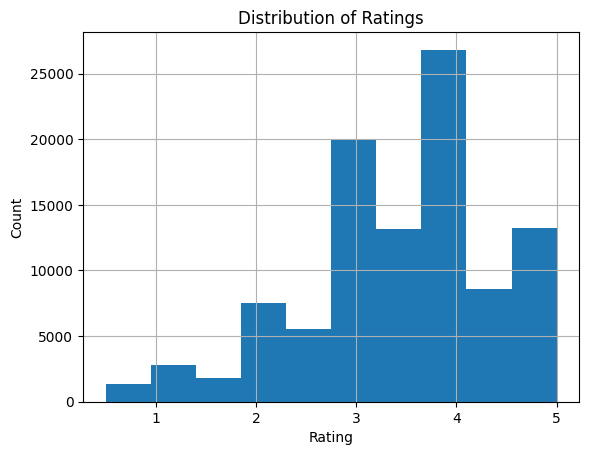

In [20]:
import matplotlib.pyplot as plt
ratings['rating'].hist(bins=10)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of Ratings")
plt.show()

Podemos ver que os ratings vão aumentando gradualmente a partir do 0.5, sendo mais baixos os ratings com casas décimais, e depois perto do 5 baixa drásticamente. <br>
Isto é ao contrário de muitos outros exemplos de ratings onde geralmente se observam picos nas extremidades, este pelo contrário é mais equilibrado e realista.

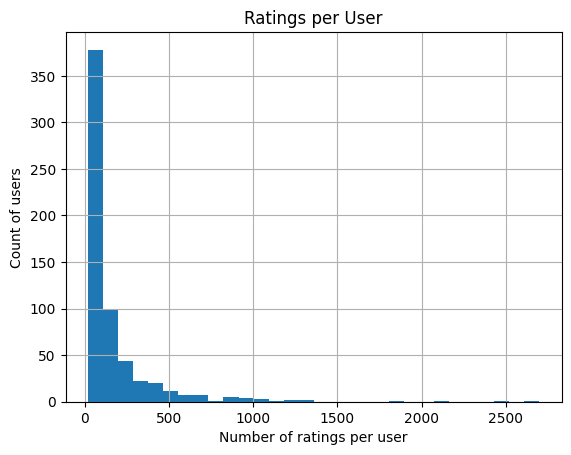

In [21]:
user_rating_counts = ratings.groupby('userId')['rating'].count()

user_rating_counts.hist(bins=30)
plt.xlabel("Number of ratings per user")
plt.ylabel("Count of users")
plt.title("Ratings per User")
plt.show()

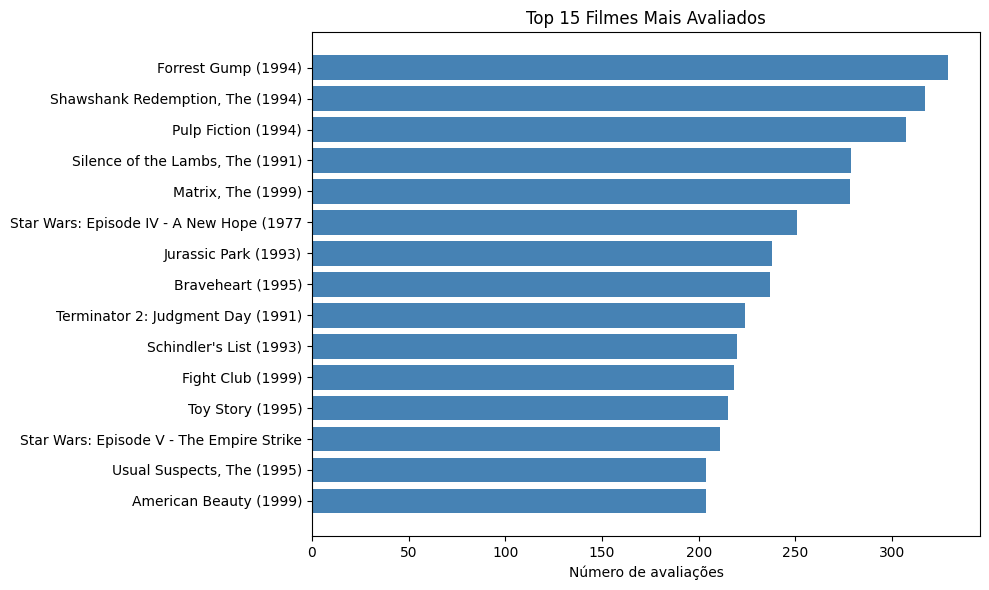

In [22]:
# GRÁFICO 1 — Top 15 filmes mais avaliados
top_rated = ratings.groupby('movieId').size().reset_index(name='count')
top_rated = top_rated.merge(movies[['movieId', 'title']], on='movieId')
top_rated = top_rated.nlargest(15, 'count')

plt.figure(figsize=(10, 6))
plt.barh(top_rated['title'].str[:40], top_rated['count'], color='steelblue')
plt.title('Top 15 Filmes Mais Avaliados')
plt.xlabel('Número de avaliações')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

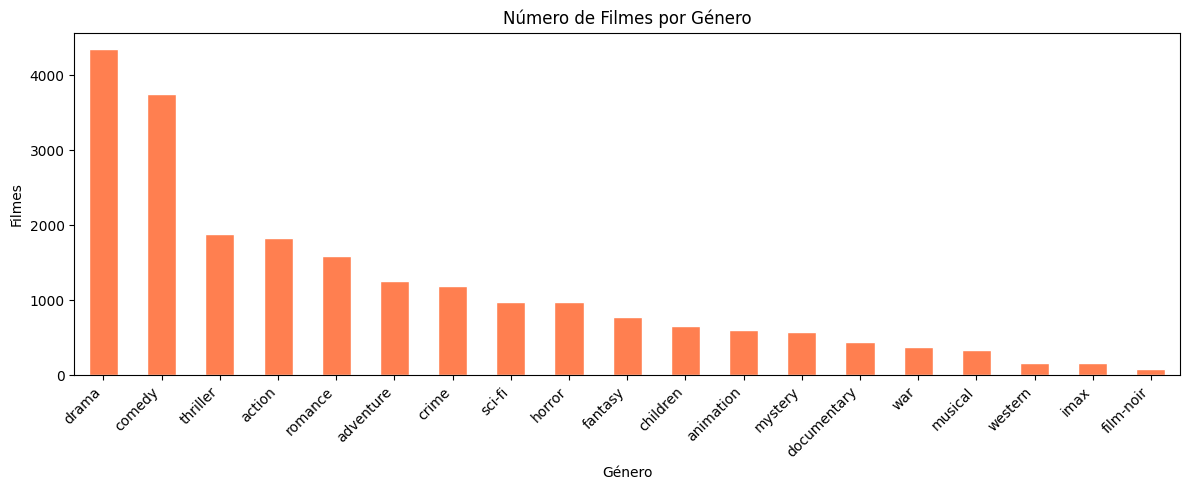

In [23]:
# GRÁFICO 2 — Número de filmes por género
genre_counts = movies['genres'].explode().value_counts()

plt.figure(figsize=(12, 5))
genre_counts.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Número de Filmes por Género')
plt.xlabel('Género')
plt.ylabel('Filmes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Os géneros de longe mais comuns existindo em mais de 1/3 dos filmes totais (9724) são drama e comedy. Depois destes também vemos que as proporções são mais equilibradas mas seguem-se thriller e action.

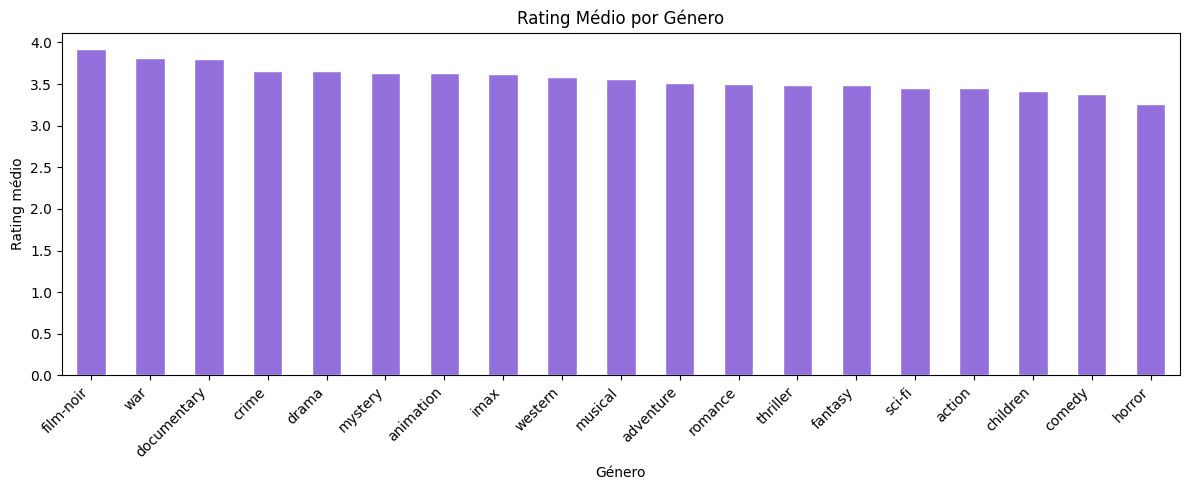

In [24]:
# GRÁFICO 4 — Rating médio por género
genre_ratings = (
    ratings.merge(movies[['movieId', 'genres']], on='movieId')
    .explode('genres')
    .dropna(subset=['genres'])
)
genre_avg = genre_ratings.groupby('genres')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
genre_avg.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Rating Médio por Género')
plt.xlabel('Género')
plt.ylabel('Rating médio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


O melhor avaliado é curiosamente o mais nicho, mas mesmo assim, a diferença de ratings entre filmes não é extremamente notória.

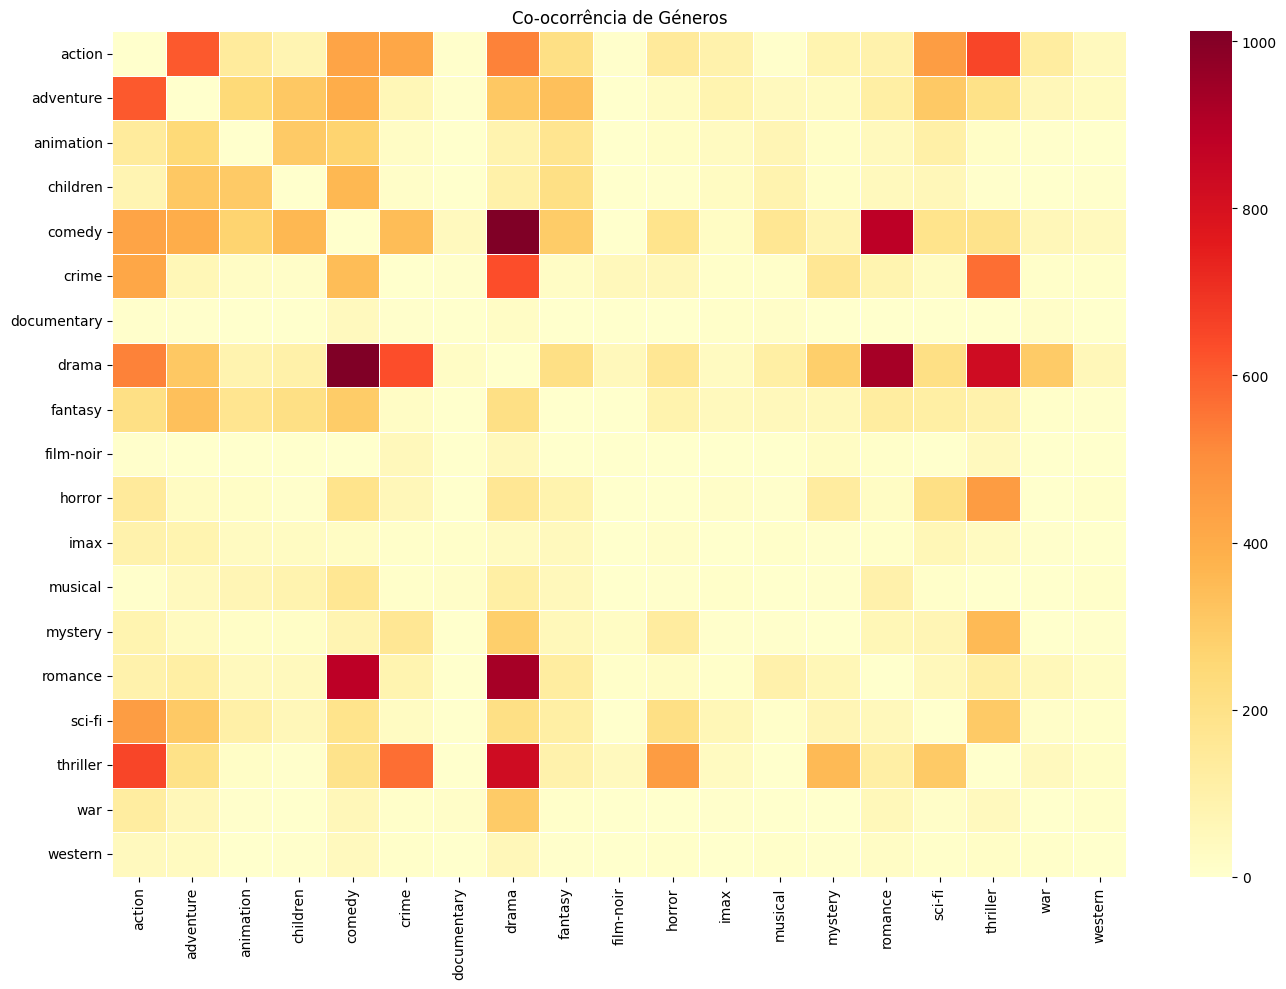

In [25]:
# GRÁFICO 5 — Heatmap co-ocorrência de géneros
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(movies['genres'])
co_occ = genre_matrix.T @ genre_matrix
np.fill_diagonal(co_occ, 0)
co_occ_df = pd.DataFrame(co_occ, index=mlb.classes_, columns=mlb.classes_)

plt.figure(figsize=(14, 10))
sns.heatmap(co_occ_df, cmap='YlOrRd', annot=False, linewidths=0.5)
plt.title('Co-ocorrência de Géneros')
plt.tight_layout()
plt.show()


Podemos notar que há géneros muito correlacionados, notando-se muito forte cooexistencia de comédias também serem dramas, também forte probabilidade de dramas serem romances, de comédias serem romances e ainda alguma probabilidade de dramas serem thrillers, e vice-versa.<br>
Estas coexistências são expectáveis na sua maioria tendo em conta que drama, comédia e thriller são os géneros mais comuns, portanto estarão repetidos em vários filmes.

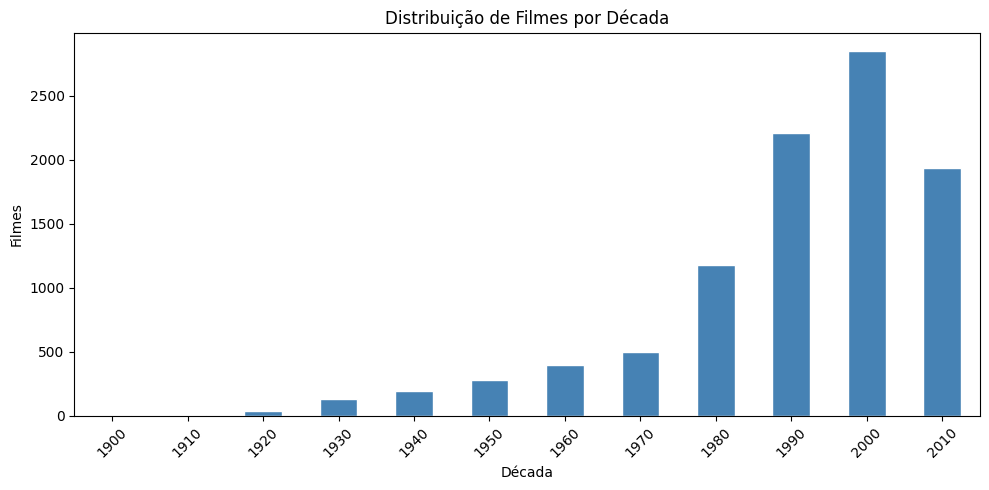

In [26]:
movies['year'].apply(lambda x: int(float(x) // 10 * 10)).value_counts().sort_index().plot(
    kind='bar', figsize=(10, 5), color='steelblue', edgecolor='white'
)
plt.title('Distribuição de Filmes por Década')
plt.xlabel('Década')
plt.ylabel('Filmes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


encoding

encoding da variável genres

In [27]:
from mlxtend.preprocessing import TransactionEncoder

genres = movies['genres'].tolist()   # lista de tuplas de géneros

encoder = TransactionEncoder()
genres_encoded = encoder.fit_transform(genres)          # True/False
genres_df = pd.DataFrame(genres_encoded.astype(int), columns=encoder.columns_)

print(genres_df.shape)   # (9714, 19)
genres_df.head()


(9714, 19)


,action,adventure,animation,children,comedy,crime,documentary,drama,fantasy,film-noir,horror,imax,musical,mystery,romance,sci-fi,thriller,war,western
0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


scaling das variáveis numéricas no dataset movies

In [28]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
num_scaled = sc.fit_transform(movies[['avg_rating', 'year']].astype(float))
num_df = pd.DataFrame(num_scaled, columns=['avg_rating', 'year'])

num_df.head()

,avg_rating,year
0,0.758178,0.01802
1,0.195376,0.01802
2,-0.002771,0.01802
3,-1.041211,0.01802
4,-0.219310,0.01802


Adicionar uma variável com a quantidade de ratings cada filme teve

In [60]:
movies['n_ratings'] = movies['movieId'].map(
    ratings.groupby('movieId')['rating'].count()
)

sc = StandardScaler()
num_scaled = sc.fit_transform(movies[['avg_rating', 'year', 'n_ratings']].astype(float))
num_df = pd.DataFrame(num_scaled, columns=['avg_rating', 'year', 'n_ratings']) 


Concatenar numa matriz de features

In [61]:
features_df = pd.concat([genres_df, num_df], axis=1)
features_movies = features_df.values

print(features_movies.shape)   # (9714, 21)
features_df.head()

(9714, 22)


,action,adventure,animation,children,comedy,crime,documentary,drama,fantasy,film-noir,...,musical,mystery,romance,sci-fi,thriller,war,western,avg_rating,year,n_ratings
0,0,1,1,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0.758178,0.01802,9.131006
1,0,1,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0.195376,0.01802,4.445481
2,0,0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,-0.002771,0.01802,1.857286
3,0,0,0,0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,-1.041211,0.01802,-0.150796
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,-0.219310,0.01802,1.723414


pca

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_movies)

pca_df = pd.DataFrame(features_pca, columns=['PC1', 'PC2'])
pca_df['Genre'] = movies['genres'].apply(lambda x: x[0] if len(x) > 0 else 'unknown').values

pca_df.head()

print(f"Shape antes:  {features_movies.shape}")        # (9714, 21)
print(f"Shape depois: {features_pca.shape}")    # (9714, n_components)
print(f"Variância explicada: {pca.explained_variance_ratio_.sum():.2%}")


Shape antes:  (9714, 21)
Shape depois: (9714, 2)
Variância explicada: 54.12%


In [31]:
import plotly.express as px

fig = px.scatter(
    pca_df,
    x='PC1', y='PC2',
    color='Genre',
    width=900, height=650,
    hover_data={'PC1': ':.3f', 'PC2': ':.3f', 'Genre': True}
)
fig.update_layout(
    title='PCA visualization of Movies dataset',
    xaxis_title='PCA1',
    yaxis_title='PCA2',
)
fig.show()


umap

In [32]:
from umap import UMAP
umap = UMAP( n_neighbors=15, random_state=1)
umap_features = umap.fit_transform(features_movies)
umap_features.shape


c:\Users\rafae\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(9714, 2)

In [33]:
umap_df = pd.DataFrame({
    'UMAP1': umap_features[:, 0],
    'UMAP2': umap_features[:, 1],
    'Genre': movies['genres'].apply(lambda x: x[0] if len(x) > 0 else 'unknown').values
})

fig = px.scatter(
    umap_df,
    x='UMAP1', y='UMAP2',
    color='Genre',
    width=900, height=650,
    hover_data={'UMAP1': ':.3f', 'UMAP2': ':.3f', 'Genre': True}
)
fig.update_layout(
    title='UMAP visualization of Movies dataset',
    xaxis_title='Embedding 1',
    yaxis_title='Embedding 2',
)
fig.show()


tsne

In [35]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=40, early_exaggeration=12, random_state=1, n_jobs=-1)
features_tsne = tsne.fit_transform(features_movies)
print("KL divergence:", tsne.kl_divergence_)

KL divergence: 1.158897876739502


In [36]:
genre_labels = movies['genres'].apply(lambda x: x[0] if len(x) > 0 else 'unknown').values

fig = px.scatter(x=features_tsne[:, 0], y=features_tsne[:, 1], color=genre_labels, width=900, height=650)
fig.update_layout(
    title='t-SNE visualization of Movies dataset',
    xaxis_title='First t-SNE',
    yaxis_title='Second t-SNE',
)
fig.show()

In [ ]:
# procurar a melhor perplexidade

perplexity = np.arange(5, 150, 5)
divergence = []

for i in perplexity:
    model = TSNE(n_components=2, perplexity=i, random_state=1, n_jobs=-1)
    reduced = model.fit_transform(features_movies)
    divergence.append(model.kl_divergence_)

fig = px.line(x=perplexity, y=divergence, markers=True)
fig.update_layout(xaxis_title="Perplexity Values", yaxis_title="Divergence", width=900, height=600)
fig.update_traces(line_color="red", line_width=1)
fig.show()


KeyboardInterrupt: 

In [37]:
tsne = TSNE(n_components=2, perplexity=15, early_exaggeration=12, random_state=1, n_jobs=-1)
features_tsne = tsne.fit_transform(features_movies)
print("KL divergence:", tsne.kl_divergence_)

KL divergence: 1.1102163791656494


In [38]:
genre_labels = movies['genres'].apply(lambda x: x[0] if len(x) > 0 else 'unknown').values

fig = px.scatter(x=features_tsne[:, 0], y=features_tsne[:, 1], color=genre_labels, width=900, height=650)
fig.update_layout(
    title='t-SNE visualization of Movies dataset (perplexity=15)',
    xaxis_title='First t-SNE',
    yaxis_title='Second t-SNE',
)
fig.show()


## Modelo à priori

Fizémos um modelo de recomendação que aconselha filmes com base no que outras pessoas que gostaram de um filme também gostaram.

In [39]:
# ── PREPARAÇÃO ───────────────────────────────────────────────
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Juntar ratings com títulos
df_modelo = ratings.merge(movies[['movieId', 'title']], on='movieId')

# Manter só filmes bem avaliados (liked = rating >= 4)
df_modelo = df_modelo[df_modelo['rating'] >= 4][['userId', 'title']].drop_duplicates()

df_modelo.head()

,userId,title
0,1,Toy Story (1995)
1,1,Grumpier Old Men (1995)
2,1,Heat (1995)
3,1,Seven (a.k.a. Se7en) (1995)
4,1,"Usual Suspects, The (1995)"


Para construir o sistema de recomendação com o algoritmo Apriori, começamos por preparar os dados no formato adequado.

Primeiro, cruzamos o dataset `ratings` com o dataset `movies` para associar a cada avaliação o título do filme correspondente. De seguida, filtramos apenas as avaliações positivas, consideramos que um utilizador "gostou" de um filme se lhe atribuiu uma nota igual ou superior a 4 (numa escala de 0.5 a 5).

O resultado é um dataset limpo onde cada linha representa um filme que um determinado utilizador gostou, que servirá de base para construir as transações do Apriori.

In [40]:
# ── AGRUPAR POR UTILIZADOR → lista de filmes que gostou ──────
transactions = df_modelo.groupby('userId')['title'].apply(list).tolist()

# Encode para matriz booleana
encoder = TransactionEncoder()
encoded = encoder.fit_transform(transactions)
df_encoded = pd.DataFrame(encoded, columns=encoder.columns_)

print(f"Matriz: {df_encoded.shape}  ({df_encoded.shape[0]} utilizadores × {df_encoded.shape[1]} filmes)")
df_encoded.head()

Matriz: (609, 6290)  (609 utilizadores × 6290 filmes)


,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


O algoritmo Apriori requer que os dados estejam no formato de transações — cada transação representa o conjunto de itens que ocorrem juntos. Neste contexto, cada utilizador é uma transação e os itens são os filmes que gostou.

Agrupamos os dados por utilizador e criamos uma lista de títulos para cada um. De seguida, usamos o `TransactionEncoder` para converter essas listas numa matriz booleana onde as linhas são utilizadores, as colunas são títulos de filmes, e o valor é `True` se o utilizador gostou do filme e `False` caso contrário.


In [41]:
# ── APRIORI ────────────────────────────
frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True, max_len=2)

print(f"Itemsets encontrados: {len(frequent_itemsets)}")
frequent_itemsets.sort_values('support', ascending=False).head(10)


Itemsets encontrados: 4056


,support,itemsets
267,0.449918,"frozenset({Shawshank Redemption, The (1994)})"
119,0.408867,frozenset({Forrest Gump (1994)})
244,0.400657,frozenset({Pulp Fiction (1994)})
273,0.369458,"frozenset({Silence of the Lambs, The (1991)})"
206,0.364532,"frozenset({Matrix, The (1999)})"
299,0.330049,frozenset({Star Wars: Episode IV - A New Hope ...
115,0.293924,frozenset({Fight Club (1999)})
260,0.287356,frozenset({Schindler's List (1993)})
300,0.275862,frozenset({Star Wars: Episode V - The Empire S...
2228,0.275862,"frozenset({Shawshank Redemption, The (1994), F..."


O algoritmo Apriori identificou **4056 itemsets frequentes** com um suporte mínimo de 5%, ou seja, conjuntos de filmes que aparecem juntos nas listas de pelo menos ~30 utilizadores.

Observando os resultados, os filmes com maior suporte individual são clássicos do cinema amplamente reconhecidos: *The Shawshank Redemption* lidera com 45%, quase metade dos utilizadores gostou deste filme, seguido de *Forrest Gump* (41%) e *Pulp Fiction* (40%). Isto indica que estes filmes são não só populares, mas consistentemente bem avaliados.

O primeiro par a aparecer é **Forrest Gump + Shawshank Redemption** com um suporte de 27.6%, o que significa que mais de 1 em cada 4 utilizadores gostou de ambos os filmes. Este par é um bom candidato a gerar regras de associação fortes, uma vez que ambos têm também suporte individual elevado.

De notar que o suporte elevado destes filmes não significa necessariamente que as regras entre eles sejam as mais úteis, um filme muito popular tende a co-ocorrer com quase tudo. A qualidade das regras será avaliada mais à frente através do **lift**, que controla precisamente essa popularidade.


Em seguida criámos as nossas regras de associação com base na métrica lift. Declarámos que o seu mínimo para 1.5 porque considerámos já o suficiente para ter boas associações mas não alto demais para que filmes mais nicho ficassem com poucas ou sem recomendações.

In [42]:
# ── REGRAS DE ASSOCIAÇÃO ─────────────────────────────────────
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.5)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f"Regras geradas: {len(rules)}")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)


Regras geradas: 6226


,antecedents,consequents,support,confidence,lift
0,frozenset({Shaun of the Dead (2004)}),frozenset({Hot Fuzz (2007)}),0.052545,0.603774,8.754717
1,frozenset({Hot Fuzz (2007)}),frozenset({Shaun of the Dead (2004)}),0.052545,0.761905,8.754717
2,frozenset({Harry Potter and the Sorcerer's Sto...,frozenset({Harry Potter and the Chamber of Sec...,0.062397,0.655172,8.312500
3,frozenset({Harry Potter and the Chamber of Sec...,frozenset({Harry Potter and the Sorcerer's Sto...,0.062397,0.791667,8.312500
4,frozenset({Spider-Man (2002)}),frozenset({Spider-Man 2 (2004)}),0.052545,0.542373,8.056222
5,frozenset({Spider-Man 2 (2004)}),frozenset({Spider-Man (2002)}),0.052545,0.780488,8.056222
6,frozenset({Harry Potter and the Chamber of Sec...,frozenset({Harry Potter and the Prisoner of Az...,0.055829,0.708333,7.071721
7,frozenset({Harry Potter and the Prisoner of Az...,frozenset({Harry Potter and the Chamber of Sec...,0.055829,0.557377,7.071721
8,frozenset({X2: X-Men United (2003)}),frozenset({X-Men (2000)}),0.057471,0.795455,6.822983
9,frozenset({X-Men (2000)}),frozenset({X2: X-Men United (2003)}),0.057471,0.492958,6.822983


O algoritmo gerou **7238 regras de associação**, ordenadas por lift decrescente. As regras com lift mais elevado revelam padrões intuitivos e interpretáveis.

As associações mais fortes são entre filmes da **mesma saga ou do mesmo realizador**: *Hot Fuzz* e *Shaun of the Dead* (ambos de Edgar Wright) lideram com um lift de **8.75**, seguidos dos filmes de *Harry Potter* e *Spider-Man*. Um lift tão elevado indica que estas associações vão muito além da popularidade individual dos filmes, quem gosta de um tem uma probabilidade muito superior à média de gostar do outro.

Analisando a **confiança**, é possível ver assimetria nas regras: 79.2% dos utilizadores que gostaram de *Harry Potter: Chamber of Secrets* também gostaram de *Sorcerer's Stone*, enquanto o inverso é 65.5%. Isto significa que os fãs de *Chamber of Secrets* são mais "fiéis" à saga do que os fãs de *Sorcerer's Stone*, possivelmente por *Sorcerer's Stone* ter um público mais casual.

Em suma, o modelo captura naturalmente **lealdade a franquias e afinidade por realizadores**, que são precisamente os padrões mais úteis num sistema de recomendação. Se um utilizador gostou de um filme de uma saga, é altamente provável que goste dos restantes.


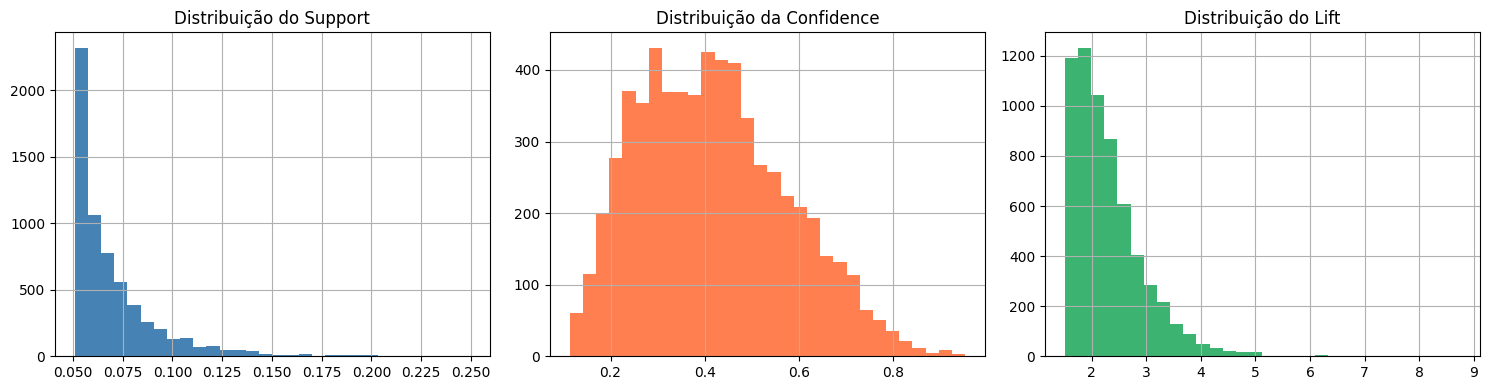

In [43]:
# Análise das regras — distribuição das métricas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rules['support'].hist(bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição do Support')

rules['confidence'].hist(bins=30, ax=axes[1], color='coral')
axes[1].set_title('Distribuição da Confidence')

rules['lift'].hist(bins=30, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Distribuição do Lift')

plt.tight_layout()
plt.show()


Support — distribuição muito assimétrica à esquerda. A maioria das regras tem support baixo (perto de 0.05, o mínimo definido), o que é esperado num dataset de filmes — pares de filmes específicos são naturalmente vistos por poucos utilizadores em comum. Apenas alguns pares muito populares atingem support acima de 0.15.

Confidence — distribuição mais equilibrada, centrada entre 0.2 e 0.6. Isto significa que, em média, quando um utilizador gostou do filme antecedente, há 20-60% de probabilidade de também gostar do consequente. Regras com confidence acima de 0.7 existem mas são raras — correspondem a pares muito fortemente ligados (como sequelas ou filmes do mesmo realizador).

Lift — a grande maioria das regras tem lift entre 1.5 e 3, com poucos casos acima de 5. Isto é saudável — todas as regras têm lift > 1.5 (definido pelo threshold), confirmando que todas as associações são genuínas e não aleatórias. Os valores extremos (lift > 6) correspondem às associações mais fortes do dataset, como Hot Fuzz → Shaun of the Dead.

Conclusão geral: o modelo gera regras com associações reais e significativas. O support baixo é uma característica do domínio (não um problema), a confidence moderada é realista para dados de filmes, e o lift consistentemente acima de 1 confirma que o algoritmo está a capturar padrões genuínos de comportamento dos utilizadores.

In [72]:
# ── FUNÇÃO DE RECOMENDAÇÃO ────────────────────────────────────
def apriori_recommend(movie_title, rules_df, n=5):
    # filtra regras onde o filme está como antecedente
    mask = rules_df['antecedents'].apply(lambda x: movie_title in x)
    recs = rules_df[mask].copy()
    
    if recs.empty:
        return f"Sem recomendações para '{movie_title}'"
    
    # extrai os títulos consequentes e ordena por lift
    recs['recommended'] = recs['consequents'].apply(lambda x: list(x)[0])
    return recs[['recommended', 'confidence', 'lift']].head(n).reset_index(drop=True)

# Exemplo
apriori_recommend('Toy Story (1995)', rules)


,recommended,confidence,lift
0,Toy Story 2 (1999),0.312925,3.403061
1,Mary Poppins (1964),0.210884,2.518207
2,Babe (1995),0.292517,2.375238
3,Willy Wonka & the Chocolate Factory (1971),0.299320,2.367347
4,Jaws (1975),0.224490,2.317191


A função `recommend` aplica as regras de associação geradas para recomendar filmes a partir de um título dado. Para um filme de entrada, filtra todas as regras onde esse filme é o antecedente e devolve os consequentes ordenados por lift.

**Exemplo — Toy Story (1995):**
Os resultados fazem sentido contextual: *Toy Story 2* é a continuação direta e lidera com o lift mais alto (3.4), seguido de filmes como *Mary Poppins*, *Babe* e *Willy Wonka*, todos filmes familiares e infantis da mesma época. O modelo capturou implicitamente o perfil de utilizadores que gostam de animação e cinema familiar, sem nunca ter recebido essa informação explicitamente.

A confiança indica a probabilidade de um utilizador que gostou de *Toy Story* vir a gostar do filme recomendado — por exemplo, 31.3% dos utilizadores que gostaram de *Toy Story* também gostaram de *Toy Story 2*. O lift confirma que esta associação é 3.4 vezes mais forte do que seria esperado por acaso.

SOM

In [63]:
from sklearn.preprocessing import StandardScaler
import math
from minisom import MiniSom

n_samples  = features_movies.shape[0]
n_features = features_movies.shape[1]

print(f"Samples: {n_samples}, Features: {n_features}")


Samples: 9714, Features: 22


In [64]:
map_size   = 5 * math.sqrt(n_samples)
map_height = map_width = math.ceil(math.sqrt(map_size))
print(f"(map_height, map_width) = ({map_height}, {map_width})")


(map_height, map_width) = (23, 23)


In [ ]:
som = MiniSom(map_width, map_height, n_features, sigma=1.5, learning_rate=0.5, neighborhood_function='gaussian', random_seed=1)
som.random_weights_init(features_movies)

n_iterations = 4000
quantization_errors = []
for i in range(n_iterations):
    som.train_random(features_movies, i + 1)
    quantization_errors.append(som.quantization_error(features_movies))

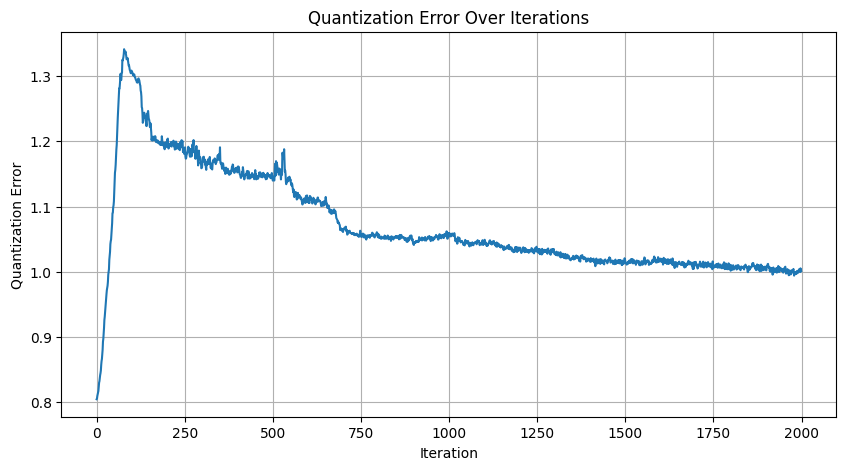

In [66]:
plt.figure(figsize=(10, 5))
plt.plot(quantization_errors)
plt.title('Quantization Error Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Quantization Error')
plt.grid(True)
plt.show()


In [67]:
winning_neurons = np.array([som.winner(x) for x in features_movies])
offset = np.random.uniform(-0.4, 0.4, size=winning_neurons.shape)
wn = winning_neurons + offset

som_df = pd.DataFrame({
    'x': wn[:, 0],
    'y': wn[:, 1],
    'Genre': movies['genres'].apply(lambda x: x[0] if len(x) > 0 else 'unknown').values,
    'Title': movies['title'].values
})

fig = px.scatter(
    som_df,
    x='x', y='y',
    color='Genre',
    hover_data={'Title': True, 'Genre': True, 'x': False, 'y': False},
    width=900, height=650
)
fig.update_layout(
    title='SOM visualization of Movies dataset',
    xaxis_title='SOM x',
    yaxis_title='SOM y',
)
fig.show()


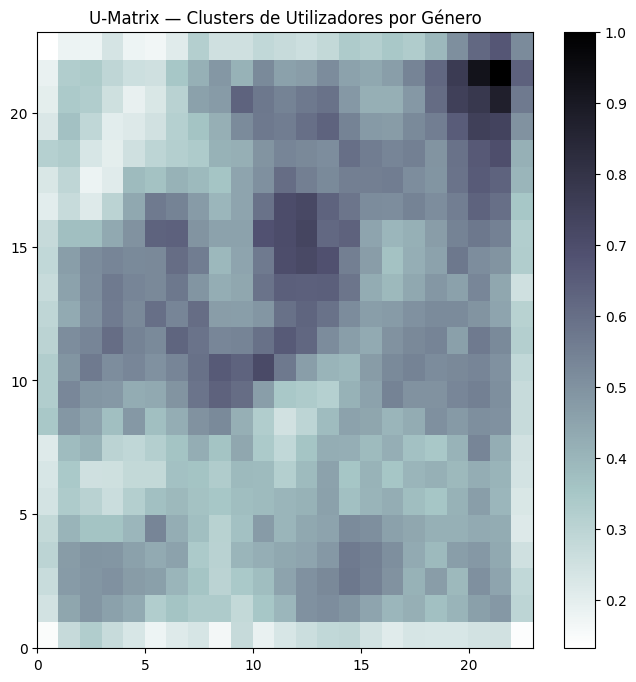

In [68]:
plt.figure(figsize=(8, 8))
u_matrix = som.distance_map().T
plt.pcolor(u_matrix, cmap='bone_r')
plt.colorbar()
plt.title('U-Matrix — Clusters de Utilizadores por Género')
plt.show()


In [69]:
def recommend_som(movie_title, som, features, movies_df, n=5):
    idx = movies_df[movies_df['title'] == movie_title].index
    if len(idx) == 0:
        return f"Filme '{movie_title}' não encontrado"
    idx = idx[0]

    winner = som.winner(features[idx])

    recs = [
        movies_df.iloc[i][['title', 'genres', 'avg_rating']]
        for i in range(len(features))
        if som.winner(features[i]) == winner and i != idx
    ]

    return pd.DataFrame(recs)\
             .sort_values('avg_rating', ascending=False)\
             .head(n)\
             .reset_index(drop=True)

recommend_som('Toy Story (1995)', som, features_movies, movies)


,title,genres,avg_rating
0,Star Wars: Episode V - The Empire Strikes Back...,"(action, adventure, sci-fi)",4.215640
1,Raiders of the Lost Ark (Indiana Jones and the...,"(action, adventure)",4.207500
2,Star Wars: Episode VI - Return of the Jedi (1983),"(action, adventure, sci-fi)",4.137755
3,"Lord of the Rings: The Fellowship of the Ring,...","(adventure, fantasy)",4.106061


## Comparação SOM vs À Priori

| Critério | Apriori | SOM |
|---|---|---|
| Tipo de filtragem | Collaborative filtering | Content-based filtering |
| Base da recomendação | Comportamento de utilizadores | Características do filme |
| Input | Título do filme | Título do filme |
| Dataset usado | ratings + movies | movies (géneros + avg_rating + year + n_ratings) |
| Lógica | Quem gostou de A também gostou de B | A e B têm conteúdo semelhante |
| Vantagem | Captura padrões reais de consumo | Funciona sem histórico de utilizadores |
| Desvantagem | Filmes nicho ficam sem recomendações | Ignora preferências reais dos utilizadores |


In [83]:
# Três filmes de teste
test_films = ['Toy Story (1995)', 'Jumanji (1995)', 'Fight Club (1999)']

for film in test_films:
    apr = apriori_recommend(film, rules, n=5)
    s   = recommend_som(film, som, features_movies, movies, n=5)
    print(f"\n{'='*60}")
    print(f"Filme de input: {film}")
    print(f"{'─'*60}")
    print("Apriori (ordenado por lift):")
    if isinstance(apr, str):
        print(f"  {apr}")
    elif apr.empty:
        print("  Sem recomendações (suporte insuficiente)")
    else:
        for _, row in apr.iterrows():
            print(f"  {row['recommended']:<45} lift={row['lift']:.2f}  conf={row['confidence']:.2f}")
    print("SOM (mesmo neurónio no mapa):")
    if isinstance(s, str):
        print(f"  {s}")
    elif s.empty:
        print("  Sem vizinhos no mesmo neurónio")
    else:
        for _, row in s.iterrows():
            print(f"  {row['title']:<45} avg_rating={row['avg_rating']:.2f}")



Filme de input: Toy Story (1995)
────────────────────────────────────────────────────────────
Apriori (ordenado por lift):
  Toy Story 2 (1999)                            lift=3.40  conf=0.31
  Mary Poppins (1964)                           lift=2.52  conf=0.21
  Babe (1995)                                   lift=2.38  conf=0.29
  Willy Wonka & the Chocolate Factory (1971)    lift=2.37  conf=0.30
  Jaws (1975)                                   lift=2.32  conf=0.22
SOM (mesmo neurónio no mapa):
  Star Wars: Episode V - The Empire Strikes Back (1980) avg_rating=4.22
  Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981) avg_rating=4.21
  Star Wars: Episode VI - Return of the Jedi (1983) avg_rating=4.14
  Lord of the Rings: The Fellowship of the Ring, The (2001) avg_rating=4.11

Filme de input: Jumanji (1995)
────────────────────────────────────────────────────────────
Apriori (ordenado por lift):
  Lion King, The (1994)                         lift=3.71  conf=0.

In [ ]:
test_films = ['Toy Story (1995)', 'Pulp Fiction (1994)', 'Jumanji (1995)']

rows = []
for film in test_films:
    apr = apriori_recommend(film, rules, n=5)
    s   = recommend_som(film, som, features_movies, movies, n=5)

    apr_titles = apr['recommended'].tolist() if not isinstance(apr, str) else []
    som_titles = s['title'].tolist()         if not isinstance(s, str)   else []

    # padding para garantir 5 linhas por filme
    apr_titles += ['—'] * (5 - len(apr_titles))
    som_titles += ['—'] * (5 - len(som_titles))

    for i, (a, s_) in enumerate(zip(apr_titles, som_titles)):
        rows.append({
            'Filme de Input': film if i == 0 else '',
            'Rank': i + 1,
            'Apriori': a,
            'SOM': s_
        })

comp_df = pd.DataFrame(rows).set_index(['Filme de Input', 'Rank'])
display(comp_df)


In [86]:
# ── MÉTRICAS QUANTITATIVAS DE COMPARAÇÃO ────────────────────────────────────

# --- Apriori ---
n_rules          = len(rules)
avg_lift         = rules['lift'].mean()
avg_conf         = rules['confidence'].mean()
avg_support      = rules['support'].mean()
movies_as_ant    = len(set(m for s in rules['antecedents'] for m in s))
apriori_coverage = movies_as_ant / df_encoded.shape[1] * 100

# --- SOM ---
qe              = som.quantization_error(features_movies)
winning_neurons = [som.winner(x) for x in features_movies]
unique_bmus     = len(set(winning_neurons))
total_neurons   = map_height * map_width
som_coverage    = unique_bmus / total_neurons * 100

# --- Tabela ---
summary = pd.DataFrame({
    'Métrica': [
        'Tipo de abordagem',
        'Dados utilizados',
        'N.º de regras / neurónios activos',
        'Cobertura do catálogo',
        'Métrica de qualidade principal',
        'Valor da métrica de qualidade',
        'Interpretabilidade da recomendação',
        'Filmes sem dados de utilizador',
    ],
    'Apriori': [
        'Association Rule Mining',
        'Comportamento dos utilizadores (ratings ≥ 4)',
        f'{n_rules} regras geradas',
        f'{apriori_coverage:.1f}% dos filmes cobertos como antecedentes',
        'Lift médio das regras',
        f'{avg_lift:.3f}  (conf={avg_conf:.3f}, sup={avg_support:.3f})',
        'Alta — regra explícita A → B com lift e confiança',
        'Sem recomendação (suporte insuficiente)',
    ],
    'SOM': [
        'Rede neuronal não supervisionada (Kohonen)',
        'Features do filme (géneros, avg_rating, year, n_ratings)',
        f'{unique_bmus}/{total_neurons} neurónios activos ({som_coverage:.1f}%)',
        '100% — todos os filmes têm um BMU atribuído',
        'Quantization Error',
        f'{qe:.4f}  (distância média ao BMU)',
        'Média — vizinhança geográfica no mapa 2D',
        'Recomenda sempre (via features de conteúdo)',
    ]
}).set_index('Métrica')

display(summary)


,Apriori,SOM
Métrica,,
Tipo de abordagem,Association Rule Mining,Rede neuronal não supervisionada (Kohonen)
Dados utilizados,Comportamento dos utilizadores (ratings ≥ 4),"Features do filme (géneros, avg_rating, year, ..."
N.º de regras / neurónios activos,6226 regras geradas,500/529 neurónios activos (94.5%)
Cobertura do catálogo,3.8% dos filmes cobertos como antecedentes,100% — todos os filmes têm um BMU atribuído
Métrica de qualidade principal,Lift médio das regras,Quantization Error
Valor da métrica de qualidade,"2.296 (conf=0.418, sup=0.071)",1.0009 (distância média ao BMU)
Interpretabilidade da recomendação,Alta — regra explícita A → B com lift e confiança,Média — vizinhança geográfica no mapa 2D
Filmes sem dados de utilizador,Sem recomendação (suporte insuficiente),Recomenda sempre (via features de conteúdo)
